# NYC：总体表现与 recourse 对比（两张图）

读取 `results/continuous_nyc_results` 中六份连续三天评估的原始 Excel，不修改工作簿。
从上到下运行，在该目录的 `paper_figures/` 生成两张 PNG 和两张 PDF，数据表保存到 `analysis/`。

图 1 比较六种方法的日均系统 reward、未获同轮 recourse 的拒单量、总体服务率和包含预约的平均队列长度。
图 2 沿用 `plot.ipynb` 的每小时完成订单曲线＋需求 KDE 背景，一行三列分别展示三天，只比较 Learning r1、Learning r2、Decoupled r3、Macro。图下另列 Macro–r3 的拒单事件、重复拒单与补救完成统计。


In [27]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'results/continuous_nyc_results').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('请从 icaps 项目或其子目录运行 notebook。')
DATA_DIR = ROOT / 'results/continuous_nyc_results'
FIG_DIR = DATA_DIR / 'paper_figures'
ANALYSIS_DIR = DATA_DIR / 'analysis'
FIG_DIR.mkdir(exist_ok=True)
ANALYSIS_DIR.mkdir(exist_ok=True)
EPOCH_SECONDS = 30.0  # 与这些导出结果的 NYC 测试设置一致
SPECS = [
    ('myopic_r1', 'Myopic r1', 'MCMF', 'r1', '#697786'),
    ('myopic_r2', 'Myopic r2', 'MCMF', 'r2', '#b28c57'),
    ('r1', 'Learning r1', 'ADP-MCMF', 'r1', '#4c78a8'),
    ('r2', 'Learning r2', 'ADP-MCMF', 'r2', '#9b6cb3'),
    ('r3', 'Learning r3', 'ADP-MCMF', 'r3', '#e48144'),
    ('macro', 'Macro', 'ADP-MCMF', 'macro', '#219b89'),
]
ORDER = [s[1] for s in SPECS]
COLORS = {s[1]: s[4] for s in SPECS}
STYLE = {label: '--' if label.startswith('Myopic') else '-' for label in ORDER}
mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': .18, 'axes.axisbelow': True,
    'figure.dpi': 300, 'savefig.dpi': 300, 'pdf.fonttype': 42,
})
FIGURES = []

def save_show(fig, name, description):
    for suffix in ['png', 'pdf']:
        fig.savefig(FIG_DIR / f'{name}.{suffix}', bbox_inches='tight', facecolor='white')
    FIGURES.append({'name': name, 'description': description})
    plt.show()
    plt.close(fig)

def line(ax, label, x, y, **kwargs):
    ax.plot(x, y, color=COLORS[label], linestyle=STYLE[label],
            linewidth=2.1, label=label, **kwargs)

def bars(ax, values, title, ylabel, fmt='.1f'):
    values = np.asarray(values, dtype=float)
    rects = ax.bar(np.arange(len(ORDER)), values, color=[COLORS[s] for s in ORDER], width=.7)
    for label, rect in zip(ORDER, rects):
        if label.startswith('Myopic'):
            rect.set_hatch('//')
            rect.set_edgecolor('white')
    ax.bar_label(rects, labels=[format(v, fmt) if np.isfinite(v) else 'n/a' for v in values],
                 padding=4, fontsize=9)
    ax.set_xticks(range(len(ORDER)), [x.replace(' ', '\n', 1) for x in ORDER])
    ax.set(title=title, ylabel=ylabel)
    ax.set_ylim(0, max(float(np.nanmax(values)) * 1.19, 1))
    ax.grid(axis='x', visible=False)

## 口径

当前为同一种子 256、2025-12-15 至 2025-12-17 三天结果。没有多种子误差带。

- reward 与 EV/AEV 完成量已经是日均；`complete`、`recourse_requests`、`lost_requests` 为三天合计，除以 3 后作图。图中分别使用百万美元/日或千单/日，数据表保留美元/日和单/日。
- 服务率 = 三天完成总量 / 三天需求总量。它与逐日服务率的等权平均略有区别。
- **平均队列是全网队列总长度的时间均值，不是每站平均，也不是分布直方图。** 先对同小时的全部站点求和，再对 72 个小时均值取平均：

\[
\bar Q_m=\frac{1}{3\times24}\sum_{d=1}^{3}\sum_{h=0}^{23}\sum_z\bar Q_{m,d,h,z}.
\]

`mean_queue_vehicle_count` 包括 **实际排队车辆 + 尚未到达的预约车辆**（`charging_queue + charging_queue_notarrived`），混合导出的站点/车辆类型。当前为 428 个站点，不能解释为 3 个 AEV 换电中心的纯到站队列。此面板保留合计口径，标为 **including reservations**；新版 detail 另有 waiting 和 reservations 分项。每站平均另存数据列，不作为主图。

- recourse = EV 拒绝后同一决策轮重新指派给 AEV 的订单数，不等于最终完成的 recourse 订单。EV/AEV 完成量和收益是该类型的全部贡献，不能全部归因于拒单补救。
- 记 $J$ 为三天内至少被 EV 拒绝一次的去重订单数（`rejected_requests`），$A$ 为其中曾在拒单同轮再指派给 AEV 的去重订单数（`recourse_requests`）。重复拒单事件数 `reject` 不作为分母。
- 图 1 第二面板为 $(J-A)/D$，其中 $D$ 是天数。它统计**未曾获得同轮 recourse 的拒单订单**；仍可能后续通过普通指派成交，不能称为最终流失数或失败数。
- 附带数据表中的 **recourse rate** 为 $100A/J$，三天先汇总计数再求比值，$J=0$ 时记为 n/a。
- 另存 **recourse completion success rate**：$100C/A$，$C$ 为已完成的 recourse 订单数。无 recourse 的 r1 记为 n/a，不记为 0%。此完成率与 $A/J$ 含义不同，且受评估终点截断影响。


In [28]:
SHEETS = ['detail', 'daily_req_completion_summary', 'hourly_req_completion_summary',
          'hourly_completed_summary', 'hourly_station_queue_summary', 'hourly_zone_vehicle_summary']
books, source_info = {}, []
for suffix, label, strategy, method, color in SPECS:
    path = DATA_DIR / f'test_results_4way_optimization_anchored_residual_continuous_{suffix}.xlsx'
    book = pd.read_excel(path, sheet_name=SHEETS)
    for sheet, frame in book.items():
        assert set(frame['strategy']) == {strategy}, (label, sheet, 'strategy mismatch')
        assert set(frame['method']) == {method}, (label, sheet, 'method mismatch')
        for col in ['date', 'request_date', 'completed_date']:
            if col in frame:
                frame[col] = pd.to_datetime(frame[col]).dt.normalize()
    # 当前文件只含一个种子。以后合并多种子时应显式新增种子层级，不能静默当日平均。
    assert len(book['detail']) == 1, f'{label}: 请为多种子结果增加种子层级聚合。'
    books[label] = book
    source_info.append({'label': label, 'file': path.name,
                        'sha256': hashlib.sha256(path.read_bytes()).hexdigest()})

raw = pd.concat([b['detail'].assign(label=label) for label, b in books.items()], ignore_index=True).set_index('label').loc[ORDER]
assert raw['seed'].nunique() == 1, '比较必须使用相同种子。'
assert raw['episodes'].nunique() == 1
N_DAYS = int(raw['episodes'].iloc[0])
SEED = int(raw['seed'].iloc[0])
DATES = sorted(books[ORDER[0]]['daily_req_completion_summary']['request_date'].unique())
assert len(DATES) == N_DAYS
PERIOD = f'{pd.Timestamp(DATES[0]):%Y-%m-%d} to {pd.Timestamp(DATES[-1]):%Y-%m-%d}; seed {SEED}'
ref_demand = None
validation_rows = []
for label, book in books.items():
    d = book['daily_req_completion_summary']
    h = book['hourly_completed_summary']
    q = book['hourly_req_completion_summary']
    assert not d.duplicated(['request_date', 'zone_id']).any()
    assert not h.duplicated(['completed_date', 'completed_hour']).any()
    assert not q.duplicated(['request_date', 'request_hour', 'zone_id']).any()
    assert sorted(d.request_date.unique()) == DATES
    demand = q.set_index(['request_date', 'request_hour', 'zone_id']).generated_requests.sort_index()
    if ref_demand is None:
        ref_demand = demand
    else:
        idx = ref_demand.index.union(demand.index)
        np.testing.assert_allclose(ref_demand.reindex(idx, fill_value=0), demand.reindex(idx, fill_value=0))
    r = raw.loc[label]
    np.testing.assert_allclose(d.generated_requests.sum(), r.total_orders)
    np.testing.assert_allclose(q.generated_requests.sum(), r.total_orders)
    np.testing.assert_allclose(d.completed_requests.sum(), r.complete)
    np.testing.assert_allclose(q.completed_requests.sum(), r.complete)
    np.testing.assert_allclose(h.mean_completed_orders.sum(), r.complete)
    np.testing.assert_allclose(h.mean_completed_ev_orders + h.mean_completed_aev_orders, h.mean_completed_orders)
    np.testing.assert_allclose(r.avg_reward * N_DAYS, r.total_reward)
    np.testing.assert_allclose(r.episode_reward_ev + r.episode_reward_aev, r.avg_reward)
    np.testing.assert_allclose((r.mean_ev_completed_orders + r.mean_aev_completed_orders) * N_DAYS, r.complete)
    validation_rows.append({'Method': label, 'Seed': SEED, 'Days': N_DAYS,
                            'Demand total': int(r.total_orders), 'Completed total': int(r.complete)})
display(pd.DataFrame(validation_rows))
print('Validated: same hourly/zone demand, same seed/dates, reward and completion totals reconcile.')
# 保留原 notebook 的便捷变量名。
data_benchmark_r1, data_benchmark_r2, data_r1, data_r2, data_r3, data_macro = [books[k]['detail'] for k in ORDER]

,Method,Seed,Days,Demand total,Completed total
0,Myopic r1,256,3,358212,174219
1,Myopic r2,256,3,358212,163135
2,Learning r1,256,3,358212,172393
3,Learning r2,256,3,358212,157240
4,Learning r3,256,3,358212,202430
5,Macro,256,3,358212,204044


Validated: same hourly/zone demand, same seed/dates, reward and completion totals reconcile.


In [29]:
metrics = pd.DataFrame(index=ORDER)
metrics.index.name = 'Method'
metrics['reward_per_day'] = raw.avg_reward
metrics['completed_per_day'] = raw.complete / N_DAYS
metrics['service_pooled_pct'] = 100 * raw.complete / raw.total_orders
metrics['service_daily_mean_pct'] = 100 * raw.mean_service_ratio
metrics['charging_wait_positive_records_min'] = raw.avg_wait * EPOCH_SECONDS / 60
metrics['waiting_records_per_day'] = raw.waiting_vehicle_count / N_DAYS
metrics['completed_charges_per_day'] = raw.finished_charge
metrics['mean_daily_final_soc_pct'] = raw.avg_battery_level * 100
metrics['recourse_per_day'] = raw.recourse_requests / N_DAYS
metrics['lost_requests_per_day'] = raw.lost_requests / N_DAYS
metrics['rejected_unique_per_day'] = raw.rejected_requests / N_DAYS

# 去重订单口径：recourse 是 EV-rejected 订单的子集；不能用重复拒单事件数 reject。
assert raw[['rejected_requests', 'recourse_requests']].notna().all().all()
assert (raw.recourse_requests >= 0).all()
assert (raw.rejected_requests >= raw.recourse_requests).all()
np.testing.assert_allclose(raw.recourse_assigned_requests, raw.recourse_requests)
assert (raw.recourse_completed_requests >= 0).all()
assert (raw.recourse_completed_requests <= raw.recourse_assigned_requests).all()
np.testing.assert_allclose(raw.recourse_completed_requests + raw.recourse_uncompleted_requests,
                           raw.recourse_assigned_requests)
metrics['rejected_without_same_epoch_recourse_total'] = raw.rejected_requests - raw.recourse_requests
metrics['rejected_without_same_epoch_recourse_per_day'] = metrics.rejected_without_same_epoch_recourse_total / N_DAYS
metrics['recourse_rate_pct'] = 100 * raw.recourse_requests / raw.rejected_requests.replace(0, np.nan)
metrics['recourse_completion_success_pct'] = 100 * raw.recourse_completed_requests / raw.recourse_assigned_requests.replace(0, np.nan)
np.testing.assert_allclose(metrics.recourse_completion_success_pct, raw.recourse_success_rate_pct, equal_nan=True)

# 先逐小时对站点（按 zone 导出）求和，再对三个完整日的 72 个小时求均值。
# mean_queue_vehicle_count 包括 charging_queue_notarrived，不是纯到站等待人数。
queue_hourly = {}
for label, book in books.items():
    s = book['hourly_station_queue_summary']
    assert not s.duplicated(['date', 'hour', 'zone_id']).any()
    hourly_queue = s.groupby(['date', 'hour'])[['mean_queue_vehicle_count', 'mean_station_count']].sum()
    expected = pd.MultiIndex.from_product([DATES, range(24)], names=['date', 'hour'])
    assert hourly_queue.index.equals(expected), f'{label}: 队列小时数据不完整'
    queue_hourly[label] = hourly_queue
    metrics.loc[label, 'mean_network_queue_including_inbound'] = hourly_queue.mean_queue_vehicle_count.mean()
    metrics.loc[label, 'mean_queue_per_exported_station'] = (hourly_queue.mean_queue_vehicle_count / hourly_queue.mean_station_count).mean()
    metrics.loc[label, 'exported_station_count'] = hourly_queue.mean_station_count.iloc[0]
    assert hourly_queue.mean_station_count.nunique() == 1
display(metrics[['reward_per_day', 'completed_per_day', 'service_pooled_pct',
                 'rejected_without_same_epoch_recourse_per_day', 'recourse_rate_pct',
                 'mean_network_queue_including_inbound', 'exported_station_count']].round(2))
metrics.to_csv(ANALYSIS_DIR / 'comparison_metrics.csv')
pd.concat(queue_hourly, names=['Method']).to_csv(ANALYSIS_DIR / 'network_queue_hourly.csv')


,reward_per_day,completed_per_day,service_pooled_pct,rejected_without_same_epoch_recourse_per_day,recourse_rate_pct,mean_network_queue_including_inbound,exported_station_count
Method,,,,,,,
Myopic r1,1309934.33,58073.00,48.64,19367.67,0.00,11.85,428.0
Myopic r2,868875.49,54378.33,45.54,10155.67,65.42,11.62,428.0
Learning r1,2452923.27,57464.33,48.13,12777.67,0.00,180.94,428.0
Learning r2,913570.32,52413.33,43.90,7518.67,68.11,16.93,428.0
Learning r3,2721944.76,67476.67,56.51,6905.33,64.63,252.76,428.0
Macro,2655871.23,68014.67,56.96,6494.67,65.69,154.06,428.0


In [36]:
compare_lists = ['strategy','mode','avg_reward', 'episode_reward_ev', 'episode_reward_aev', 'mean_ev_completed_orders', 'mean_aev_completed_orders','mean_service_ratio', 'avg_battery_level' ,"avg_wait"]
raw.columns

Index(['continuous_evaluation', 'rollouts', 'statistics_scope',
       'daily_evaluation_json', 'recourse_assigned_requests',
       'recourse_completed_requests', 'recourse_uncompleted_requests',
       'recourse_success_rate', 'recourse_success_rate_pct',
       'recourse_recovery_share', 'avg_queue_length_including_reservations',
       'avg_queue_length_waiting', 'avg_queue_length_reservations',
       'conservative_charging', 'checkpoint_conservative_charging',
       'charging_model_source', 'strategy', 'method', 'seed', 'avg_reward',
       'total_reward', 'episodes', 'total_orders', 'accept', 'reject',
       'rejected_requests', 'recourse_requests', 'lost_requests', 'complete',
       'mean_ev_completed_orders', 'mean_aev_completed_orders',
       'mean_assignment_success_rate', 'mean_completed_order_value',
       'mean_ev_completed_order_value', 'mean_aev_completed_order_value',
       'mean_service_ratio', 'max_station_pressure',
       'mean_max_station_pressure', 'mean_st

## 图 1：总体表现

第二个面板改为 **EV-rejected requests without same-epoch recourse**（千单/日，越低越好）。
它同时反映策略的拒单规模与同轮补救覆盖，不能单独归因为 recourse 模块的因果效果，也不等于最终流失订单。
其他三个面板保留。第四个面板是全网“等待＋在途预约”平均数量，不据此判断纯到站等待或严格预约是否无排队。


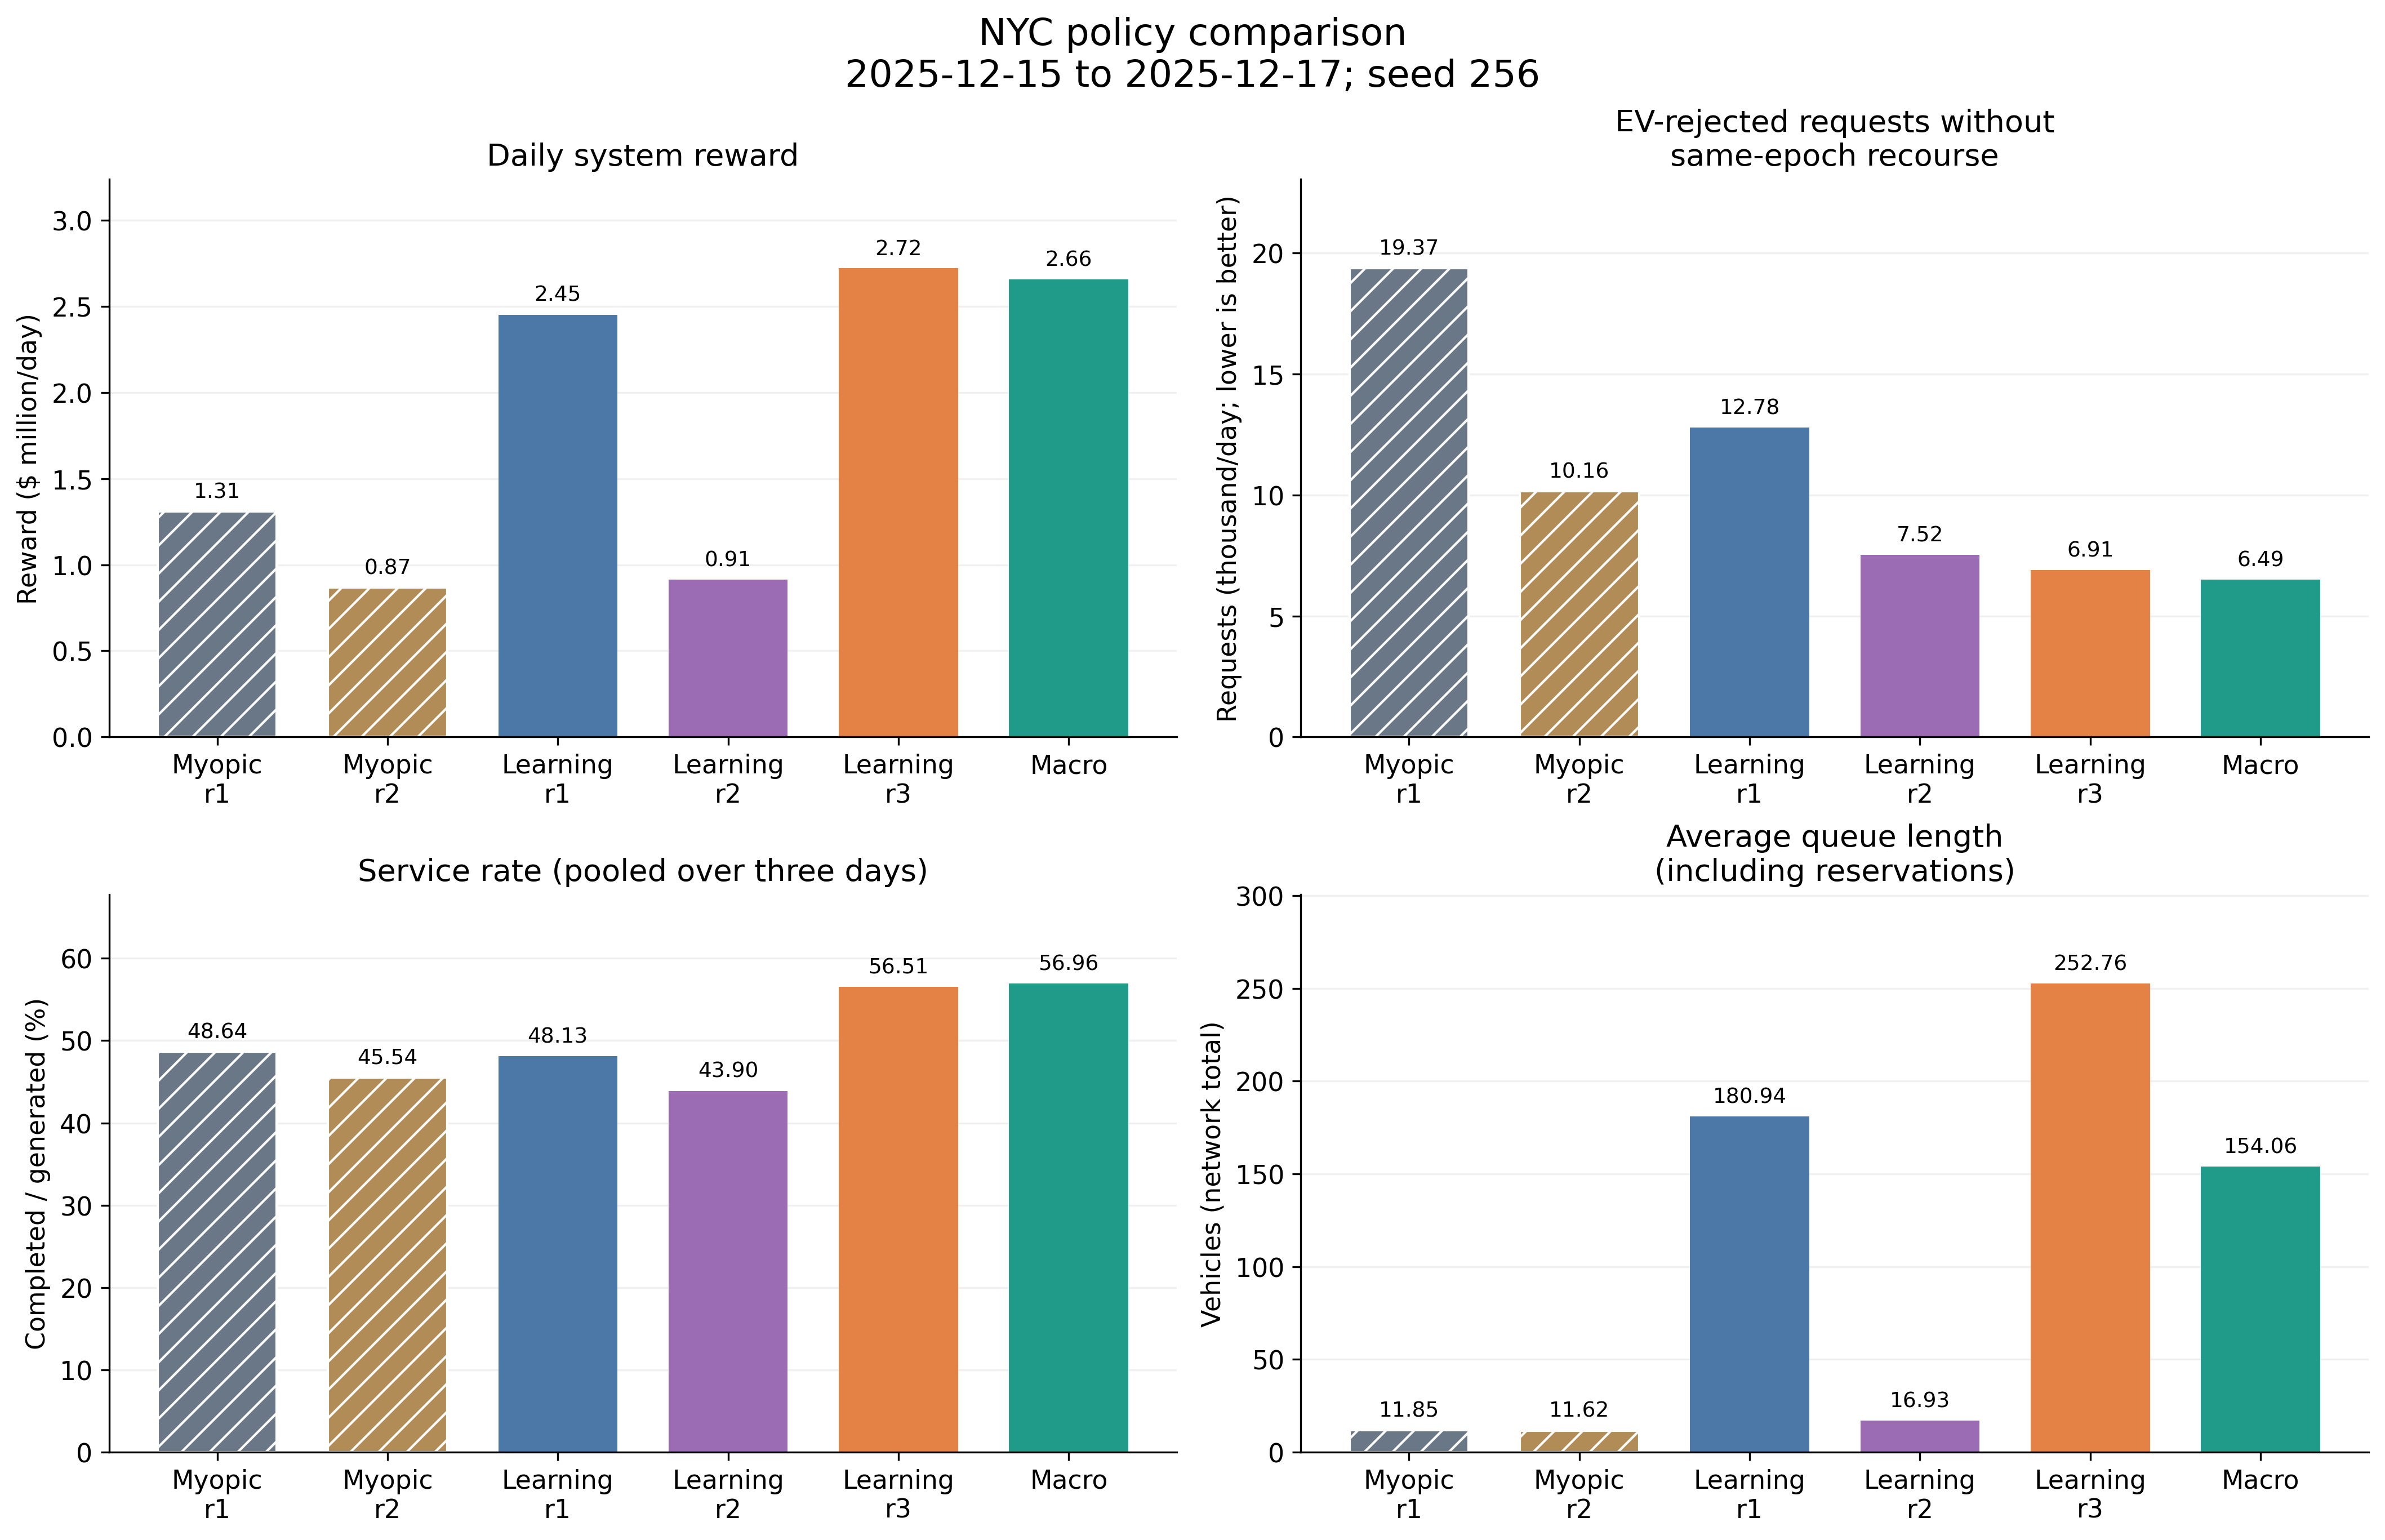

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), layout='constrained')
bars(axes[0, 0], metrics.reward_per_day / 1e6, 'Daily system reward', 'Reward ($ million/day)', '.2f')
bars(axes[0, 1], metrics.rejected_without_same_epoch_recourse_per_day / 1000,
     'EV-rejected requests without\nsame-epoch recourse', 'Requests (thousand/day; lower is better)', '.2f')
bars(axes[1, 0], metrics.service_pooled_pct, 'Service rate (pooled over three days)', 'Completed / generated (%)', '.2f')
bars(axes[1, 1], metrics.mean_network_queue_including_inbound, 'Average queue length\n(including reservations)', 'Vehicles (network total)', '.2f')
fig.suptitle('NYC policy comparison\n' + PERIOD, fontsize=16)
save_show(fig, '01_policy_overview', 'Daily reward, unique EV-rejected requests without same-epoch recourse per day, pooled service rate, mean network queue including reservations')

## 图 2：逐日完成需求与需求 KDE（一行三列）

沿用 `plot.ipynb` 的 NYC 可视化形式：**每列为一天，每列四条线分别表示 r1、r2、Decoupled r3 和 Macro 的逐小时完成订单数**，灰色阴影表示当天需求时间分布的 KDE。不加入 Myopic。

- 完成量来自 `hourly_completed_summary.mean_completed_orders`。当前每种方法只有一个种子，所以各日各小时的这一列就是实际完成订单数；不再对三天取均值。曲线以小时区间的中心为横坐标，三天使用统一纵轴。
- 需求来自同一测试的 `hourly_req_completion_summary.generated_requests`，逐日逐小时汇总全部 zone。各方法面对的需求已经逐小时核对一致。
- 只有小时粒度，因此 KDE 使用 $h+0.5$ 为样本位置、小时需求量为权重，不是订单级精确时间的 KDE。沿用旧图 `bw_method=0.7`，在 0–24 小时内归一化，再乘当天需求总量，保持 requests/hour 的单位，不按完成量峰值缩放。
- **阴影不是标准差或置信区间。** 这是一个种子的一次连续三天轨迹，三列不是三次独立实验。完成小时与订单生成小时也不同，曲线比值不能解释为该小时需求的服务率。

原始小时完成量、逐日需求、KDE 曲线及汇总表均保存到 `analysis/`。


,rejected_requests_total,recourse_requests_total,recourse_completed_requests_total,recourse_uncompleted_requests_total,rejected_without_same_epoch_recourse_total,rejected_without_same_epoch_recourse_per_day,lost_requests_total,daily_recourse_assignments,daily_lost_requests,recourse_rate_pct,recourse_completion_success_pct,recourse_over_recourse_plus_lost_pct
Method,,,,,,,,,,,,
Myopic r1,58103,0,0,0,58103,19367.67,183640,0.00,61213.33,0.00,NaN,0.00
Myopic r2,88106,57639,57639,0,30467,10155.67,194770,19213.00,64923.33,65.42,100.00,22.84
Learning r1,38333,0,0,0,38333,12777.67,185416,0.00,61805.33,0.00,NaN,0.00
Learning r2,70738,48182,48182,0,22556,7518.67,200704,16060.67,66901.33,68.11,100.00,19.36
Learning r3,58566,37850,37803,47,20716,6905.33,155223,12616.67,51741.00,64.63,99.88,19.60
Macro,56783,37299,37253,46,19484,6494.67,153520,12433.00,51173.33,65.69,99.88,19.55


Method,Learning r1,Learning r2,Learning r3,Macro
date,,,,
2025-12-15,96516,107846,97890,100121
2025-12-16,50489,37325,59327,58587
2025-12-17,25388,12069,45213,45336


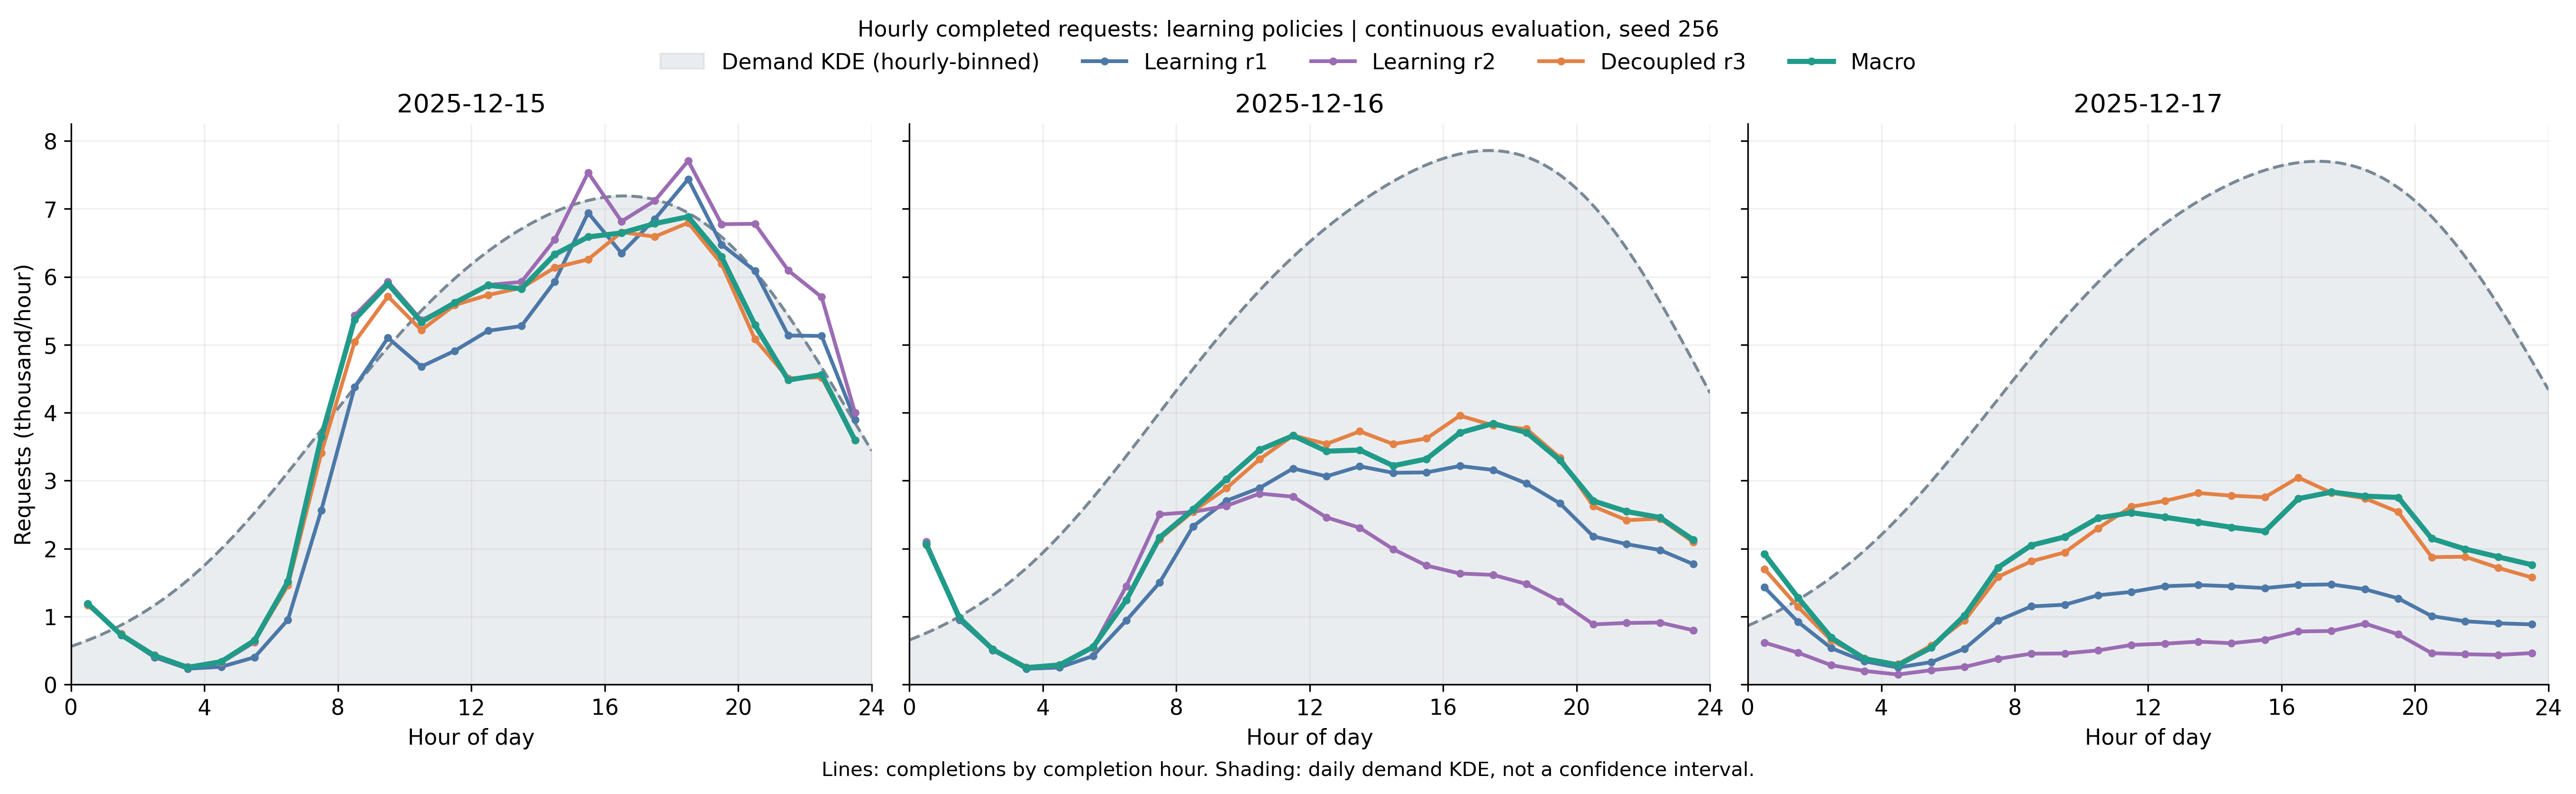

In [31]:
recourse_data = pd.DataFrame(index=ORDER)
recourse_data.index.name = 'Method'
recourse_data['rejected_requests_total'] = raw.rejected_requests
recourse_data['recourse_requests_total'] = raw.recourse_requests
recourse_data['recourse_completed_requests_total'] = raw.recourse_completed_requests
recourse_data['recourse_uncompleted_requests_total'] = raw.recourse_uncompleted_requests
recourse_data['rejected_without_same_epoch_recourse_total'] = metrics.rejected_without_same_epoch_recourse_total
recourse_data['rejected_without_same_epoch_recourse_per_day'] = metrics.rejected_without_same_epoch_recourse_per_day
recourse_data['lost_requests_total'] = raw.lost_requests
recourse_data['daily_recourse_assignments'] = raw.recourse_requests / N_DAYS
recourse_data['daily_lost_requests'] = raw.lost_requests / N_DAYS
recourse_data['recourse_rate_pct'] = metrics.recourse_rate_pct
recourse_data['recourse_completion_success_pct'] = metrics.recourse_completion_success_pct
# 旧图的描述性比值仅保留在 CSV 中，不能称为 recourse rate 或 success rate。
denominator = recourse_data.recourse_requests_total + recourse_data.lost_requests_total
recourse_data['recourse_over_recourse_plus_lost_pct'] = 100 * recourse_data.recourse_requests_total / denominator.replace(0, np.nan)
display(recourse_data.round(2))
recourse_data.to_csv(ANALYSIS_DIR / 'recourse_comparison.csv')

from scipy.stats import gaussian_kde

LEARNING_ORDER = ['Learning r1', 'Learning r2', 'Learning r3', 'Macro']
DISPLAY_LABELS = {'Learning r1': 'Learning r1', 'Learning r2': 'Learning r2',
                  'Learning r3': 'Decoupled r3', 'Macro': 'Macro'}
hours = np.arange(24)
hour_centers = hours + 0.5
expected = pd.MultiIndex.from_product([DATES, hours], names=['date', 'hour'])
completion_rows = []
hourly_profile = pd.DataFrame(index=pd.Index(hours, name='hour'))
for label in LEARNING_ORDER:
    h = books[label]['hourly_completed_summary'].rename(columns={
        'completed_date': 'date', 'completed_hour': 'hour',
        'mean_completed_orders': 'completed_orders'})
    counts = h.set_index(['date', 'hour']).completed_orders.sort_index()
    assert counts.index.equals(expected), f'{label}: incomplete hourly completion data'
    assert counts.notna().all() and (counts >= 0).all()
    hourly_profile[label] = counts.groupby('hour').mean().reindex(hours)
    np.testing.assert_allclose(hourly_profile[label].sum(), raw.loc[label, 'complete'] / N_DAYS)
    completion_rows.append(counts.rename('completed_orders').reset_index().assign(Method=label))

demand = books[LEARNING_ORDER[0]]['hourly_req_completion_summary']
demand_by_hour = demand.groupby(['request_date', 'request_hour']).generated_requests.sum()
demand_by_hour.index = demand_by_hour.index.set_names(['date', 'hour'])
assert demand_by_hour.index.equals(expected), 'Incomplete hourly demand data'
hourly_profile['generated_requests'] = demand_by_hour.groupby('hour').mean().reindex(hours)
np.testing.assert_allclose(hourly_profile.generated_requests.sum(), raw.total_orders.iloc[0] / N_DAYS)
KDE_BW_METHOD = 0.7
assert N_DAYS == 3, '当前一行三列布局需要三天评估数据。'
completion_detail = pd.concat(completion_rows, ignore_index=True)
completion_detail.to_csv(ANALYSIS_DIR / 'learning_completed_hourly.csv', index=False)
hourly_profile.to_csv(ANALYSIS_DIR / 'learning_completed_hour_of_day.csv')
demand_by_hour.rename('generated_requests').reset_index().to_csv(
    ANALYSIS_DIR / 'learning_demand_hourly.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True, layout='constrained')
kde_rows = []
for ax, date in zip(axes, DATES):
    day_demand = demand_by_hour.xs(date, level='date').reindex(hours)
    assert day_demand.notna().all() and (day_demand >= 0).all()
    kde = gaussian_kde(hour_centers, weights=day_demand.to_numpy(), bw_method=KDE_BW_METHOD)
    kde_x = np.linspace(0, 24, 481)
    kde_density = kde(kde_x) / kde.integrate_box_1d(0, 24)
    kde_rate = kde_density * day_demand.sum()
    np.testing.assert_allclose(np.trapezoid(kde_rate, kde_x), day_demand.sum(), rtol=1e-4)
    kde_rows.append(pd.DataFrame({'date': date, 'hour': kde_x,
                                  'demand_density_per_hour': kde_density,
                                  'demand_requests_per_hour': kde_rate}))
    ax.fill_between(kde_x, kde_rate / 1000, color='#aeb8c2', alpha=.25,
                    label='Demand KDE (hourly-binned)', zorder=1)
    ax.plot(kde_x, kde_rate / 1000, color='#788896', linewidth=1.5, linestyle='--', zorder=2)
    for label in LEARNING_ORDER:
        day_completed = completion_detail.loc[
            (completion_detail.Method == label) & (completion_detail.date == date)
        ].set_index('hour').completed_orders.reindex(hours)
        assert day_completed.notna().all()
        ax.plot(hour_centers, day_completed / 1000, label=DISPLAY_LABELS[label],
                color=COLORS[label], marker='o', markersize=3,
                linewidth=2.6 if label == 'Macro' else 1.9, zorder=3)
    ax.set(title=f'{pd.Timestamp(date):%Y-%m-%d}', xlabel='Hour of day', xlim=(0, 24))
    ax.set_xticks(np.arange(0, 25, 4))
axes[0].set_ylabel('Requests (thousand/hour)')
axes[0].set_ylim(bottom=0)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside upper center', ncol=5, frameon=False, fontsize=11,
           title=f'Hourly completed requests: learning policies | continuous evaluation, seed {SEED}')
fig.supxlabel('Lines: completions by completion hour. Shading: daily demand KDE, not a confidence interval.', fontsize=10)
pd.concat(kde_rows, ignore_index=True).to_csv(ANALYSIS_DIR / 'learning_demand_kde.csv', index=False)
daily_completion = completion_detail.groupby(['date', 'Method']).completed_orders.sum().unstack('Method')[LEARNING_ORDER]
display(daily_completion)
daily_completion.to_csv(ANALYSIS_DIR / 'learning_completed_daily.csv')
save_show(fig, '02_learning_completed_demand_kde',
          'One row, three calendar days: hourly completed requests for learning r1/r2, decoupled r3 and Macro with daily demand KDE')


## Macro 与 Decoupled r3：拒单与补救过程的补充比较

以下不重复主图的收益、服务率、队列和未获补救订单量，改看**拒单事件与补救过程**。

- `reject` 是拒单事件次数，同一订单可能多次被拒；`rejected_requests` 是去重订单数。
- 两者之差表示每个被拒订单首次拒单之外的额外拒单事件数，**不是重复被拒的订单数**，也不等于重复指派总次数。
- Recourse rate 是补救覆盖率；completion success 是已再指派订单在评估结束前的完成比例。
- 两个策略面对相同外部需求，但产生的拒单集合不同。因此这里是运行结果的描述性比较，不能视作同一批拒单上的配对因果实验。


In [32]:
comparison = pd.DataFrame(index=['Decoupled r3', 'Macro'])
for name, key in [('Decoupled r3', 'Learning r3'), ('Macro', 'Macro')]:
    r = raw.loc[key]
    comparison.loc[name, 'rejection_events'] = r['reject']
    comparison.loc[name, 'unique_rejected_requests'] = r.rejected_requests
    comparison.loc[name, 'repeat_rejection_events_after_first'] = r['reject'] - r.rejected_requests
    comparison.loc[name, 'rejection_events_per_rejected_request'] = r['reject'] / r.rejected_requests
    comparison.loc[name, 'same_epoch_recourse_assignments'] = r.recourse_requests
    comparison.loc[name, 'completed_recourse_requests'] = r.recourse_completed_requests
    comparison.loc[name, 'recourse_coverage_pct'] = metrics.loc[key, 'recourse_rate_pct']
    comparison.loc[name, 'recourse_completion_success_pct'] = metrics.loc[key, 'recourse_completion_success_pct']
comparison = comparison.T
comparison.index.name = 'Metric'
comparison['Macro_minus_r3'] = comparison.Macro - comparison['Decoupled r3']
comparison['relative_change_pct'] = 100 * comparison.Macro / comparison['Decoupled r3'] - 100
comparison['difference_unit'] = ['percentage points' if c.endswith('_pct') else 'native units' for c in comparison.index]
display(comparison.round(4))
comparison.to_csv(ANALYSIS_DIR / 'macro_vs_decoupled_recourse_diagnostics.csv')

from IPython.display import Markdown
event_delta = comparison.loc['rejection_events', 'relative_change_pct']
repeat_delta = comparison.loc['repeat_rejection_events_after_first', 'relative_change_pct']
coverage_delta = comparison.loc['recourse_coverage_pct', 'Macro_minus_r3']
success_delta = comparison.loc['recourse_completion_success_pct', 'Macro_minus_r3']
display(Markdown(
    f"当前 Macro 相对 r3 的拒单事件变化为 **{event_delta:+.2f}%**，"
    f"首次拒单以外的额外拒单事件变化为 **{repeat_delta:+.2f}%**；"
    f"同轮补救覆盖率变化 **{coverage_delta:+.2f} 个百分点**。"
    f"再指派后的完成率只变化 **{success_delta:+.4f} 个百分点**，基本相同。\n\n"
    "这些结果与 recourse-aware 学习改善前后阶段协调、减少反复拒单的解释相容，"
    "但仅凭一次评估不能确认机制因果。当前优势主要体现在拒单过程，"
    "而不是补救执行次数更多或补救后的完成概率更高。"
))


,Decoupled r3,Macro,Macro_minus_r3,relative_change_pct,difference_unit
Metric,,,,,
rejection_events,93835.0000,89022.0000,-4813.0000,-5.1292,native units
unique_rejected_requests,58566.0000,56783.0000,-1783.0000,-3.0444,native units
repeat_rejection_events_after_first,35269.0000,32239.0000,-3030.0000,-8.5911,native units
rejection_events_per_rejected_request,1.6022,1.5678,-0.0345,-2.1503,native units
same_epoch_recourse_assignments,37850.0000,37299.0000,-551.0000,-1.4557,native units
completed_recourse_requests,37803.0000,37253.0000,-550.0000,-1.4549,native units
recourse_coverage_pct,64.6279,65.6869,1.0590,1.6386,percentage points
recourse_completion_success_pct,99.8758,99.8767,0.0008,0.0008,percentage points


当前 Macro 相对 r3 的拒单事件变化为 **-5.13%**，首次拒单以外的额外拒单事件变化为 **-8.59%**；同轮补救覆盖率变化 **+1.06 个百分点**。再指派后的完成率只变化 **+0.0008 个百分点**，基本相同。

这些结果与 recourse-aware 学习改善前后阶段协调、减少反复拒单的解释相容，但仅凭一次评估不能确认机制因果。当前优势主要体现在拒单过程，而不是补救执行次数更多或补救后的完成概率更高。

## 保存与验证

图像保留图中数值；CSV 保留未四舍五入的数据。检查所有原始 Excel 的 SHA-256，确保来源未被改动。

In [33]:
assert len(FIGURES) == 2
for source in source_info:
    assert hashlib.sha256((DATA_DIR / source['file']).read_bytes()).hexdigest() == source['sha256'], '原始工作簿发生变化'
manifest = {'seed': SEED, 'days': N_DAYS, 'dates': [pd.Timestamp(d).strftime('%Y-%m-%d') for d in DATES],
            'epoch_seconds': EPOCH_SECONDS, 'uncertainty': 'No confidence intervals: one seed per method',
            'sources': source_info, 'figures': FIGURES,
            'completion_kde': {'methods': LEARNING_ORDER, 'hourly_bins_per_method': N_DAYS * 24,
                               'aggregation': 'Separate calendar days; no averaging across days in the figure',
                               'demand_source': 'hourly_req_completion_summary.generated_requests',
                               'kde_input': '24 hourly bin centers weighted by generated requests for that day',
                               'bw_method': KDE_BW_METHOD,
                               'normalization': 'KDE integrates over 0-24 to generated requests for that day',
                               'shading': 'Demand KDE; not uncertainty'},
            'metric_definitions': {
                'rejected_without_same_epoch_recourse_per_day': '(rejected_requests - recourse_requests) / days; unique requests, not final lost requests',
                'recourse_rate_pct': '100 * recourse_requests / rejected_requests; pooled unique requests',
                'recourse_completion_success_pct': '100 * recourse_completed_requests / recourse_assigned_requests; undefined if no assignments',
            }}
(ANALYSIS_DIR / 'paper_figures_manifest.json').write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print(f'{len(FIGURES)} figures saved as PNG + PDF to {FIG_DIR}')
display(pd.DataFrame(FIGURES))

2 figures saved as PNG + PDF to /Users/seinzhou/Desktop/icaps/results/continuous_nyc_results/paper_figures


,name,description
0,01_policy_overview,"Daily reward, unique EV-rejected requests with..."
1,02_learning_completed_demand_kde,"One row, three calendar days: hourly completed..."
